In [42]:
import pandas as pd
from sklearn.metrics import root_mean_squared_error
from sklearn.feature_extraction import DictVectorizer

from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df_jan = pd.read_parquet('https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet')
df_feb = pd.read_parquet('https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-02.parquet')
df_jan.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00


In [5]:
# Q1 Read the data for January. How many columns are there?
print("N columns =", len(df_jan.columns))
df_jan.columns

N columns = 19


Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee'],
      dtype='str')

In [6]:
# Q2. Computing duration
# Now let's compute the duration variable. It should contain the duration of a ride in minutes.
# What's the standard deviation of the trips duration in January?

In [8]:
df_jan.tpep_pickup_datetime.dtypes

dtype('<M8[us]')

In [9]:
def process_df(df):
    df["month_pickup"] = df.tpep_pickup_datetime.dt.month
    df["month_dropoff"] = df.tpep_dropoff_datetime.dt.month
    df["duration_min"] = (df.tpep_dropoff_datetime - df.tpep_pickup_datetime).dt.total_seconds() / 60

    return df
    
df_jan = process_df(df_jan)
df_feb = process_df(df_feb)

In [11]:
df_jan.duration_min.std()

np.float64(42.59435124195457)

In [12]:
# Q3. Dropping outliers

# Next, we need to check the distribution of the duration variable. There are some outliers.
# Let's remove them and keep only the records where the duration was between 1 and 60 minutes (inclusive).
# What fraction of the records left after you dropped the outliers?

In [14]:
df_jan.duration_min.describe()

count    3.066766e+06
mean     1.566900e+01
std      4.259435e+01
min     -2.920000e+01
25%      7.116667e+00
50%      1.151667e+01
75%      1.830000e+01
max      1.002918e+04
Name: duration_min, dtype: float64

In [15]:
mask_outliers_jan = (df_jan.duration_min < 1) | (df_jan.duration_min > 60)
n0 = df_jan.shape[0]
print(f"Initial n entries = {n0}")
df_jan = df_jan[~mask_outliers_jan]
n = df_jan.shape[0]
print(f"After removing outliers {n = }, or {n / n0 : .4%} ")

Initial n entries = 3066766
After removing outliers n = 3009173, or  98.1220% 


In [46]:
def clean_df(df):
    mask = (df.duration_min < 1) | (df.duration_min > 60)
    return df[~mask]

df_feb = clean_df(df_feb)

In [16]:
# Q4. One-hot encoding

"""
Let's apply one-hot encoding to the pickup and dropoff location IDs. We'll use only these two features for our model.

Turn the dataframe into a list of dictionaries (remember to re-cast the ids to strings - otherwise it will label encode them)
Fit a dictionary vectorizer
Get a feature matrix from it
What's the dimensionality of this matrix (number of columns)?
"""
""

''

In [17]:
#!pip install scikit-learn

In [19]:
df_jan.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee', 'month_pickup',
       'month_dropoff', 'duration_min'],
      dtype='str')

In [22]:

cols = ["PULocationID", "DOLocationID"]

df_aux = df_jan[cols].astype("str")
dict_aux = df_aux.to_dict(orient="records")
dv = DictVectorizer(sparse=True)
X_train = dv.fit_transform(dict_aux)
print(X_train.shape)

(3009173, 515)


In [16]:
# Q5. Training a model
"""
Now let's use the feature matrix from the previous step to train a model.

Train a plain linear regression model with default parameters, where duration is the response variable
Calculate the RMSE of the model on the training data
What's the RMSE on train?
"""
""

''

In [23]:
from sklearn.linear_model import LinearRegression

In [26]:
target = "duration_min"

In [47]:
X_test  = dv.transform(
    df_feb[cols]
        .astype("str")
        .to_dict(orient="records")
)

y_train = df_jan[target].to_numpy()
y_test  = df_feb[target].to_numpy()

print(X_train.shape, X_test.shape)

(3009173, 515) (2855951, 515)


In [31]:
model = LinearRegression()
model = model.fit(X_train, y_train)

In [32]:
preds_train = model.predict(X_train)
rmse_train = root_mean_squared_error(preds_train, y_train)
print("RMSE-train =", rmse_train)

RMSE-train = 7.649262060509152


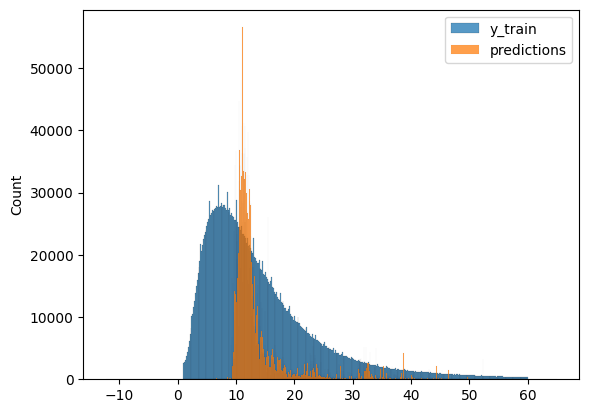

In [53]:
sns.histplot(y_train, label="y_train")
sns.histplot(preds_train, label="predictions")
plt.legend()

In [48]:
# Q6. Evaluating the model
# Now let's apply this model to the validation dataset (February 2023).
# What's the RMSE on validation?

In [49]:
preds_test = model.predict(X_test)

In [50]:

rmse_test = root_mean_squared_error(preds_test, y_test)
print("RMSE-test =", rmse_test)

RMSE-test = 7.811819098973374


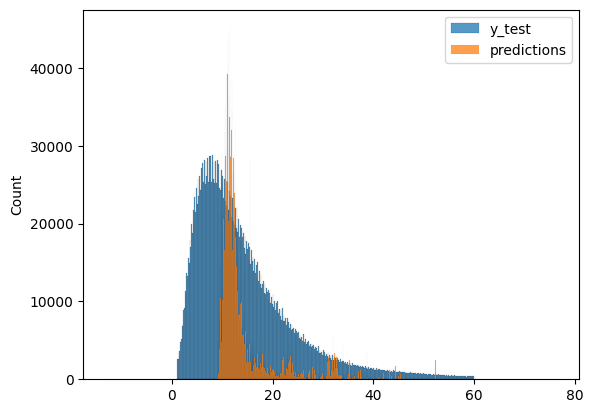

In [54]:
sns.histplot(y_test, label="y_test")
sns.histplot(preds_test, label="predictions")
plt.legend()